# Swan Consulting

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

## Read in file

In [46]:
df = pd.read_csv('1 - Project Data.csv')

## Data Cleaning

Some data columns were deemed to be unnecessary for our analysis, hence they were dropped. Further data inspection revealed that 11 total charges cells were empty. These coincided with customers whose tenure months equalled to 0 and so, these total charges cells were amended to 0.

In [47]:
#Dropping columns since they're not useful at first run
df = df.drop(columns = ['Count', 'Country', 'State', 'Lat Long', 'Latitude', 'Longitude'])

#Total Charges were empty for customers with a tenure of zero months. Populate the total charges column with 0 for such cases
df.loc[df["Tenure Months"] == 0, "Total Charges"] = 0

## Gender and Customer Characteristic Plots

How does churn rate split depending on gender, and whether the customer is a senior citizen, has a partner, or has dependents. The calculations work as follows:
- For senior citizens: 1142 customers ticked yes, while 5901 ticked no.
- We then filter these by churn value = 1.
- Within the "No" pile, 1393 churned out of 5901 customers which gives us a churn rate of 23.6%
- Within the "Yes" pile, 476 churned out of 1142 customers which gives us a churn rate of 41.7%

The same method was used for the other categories

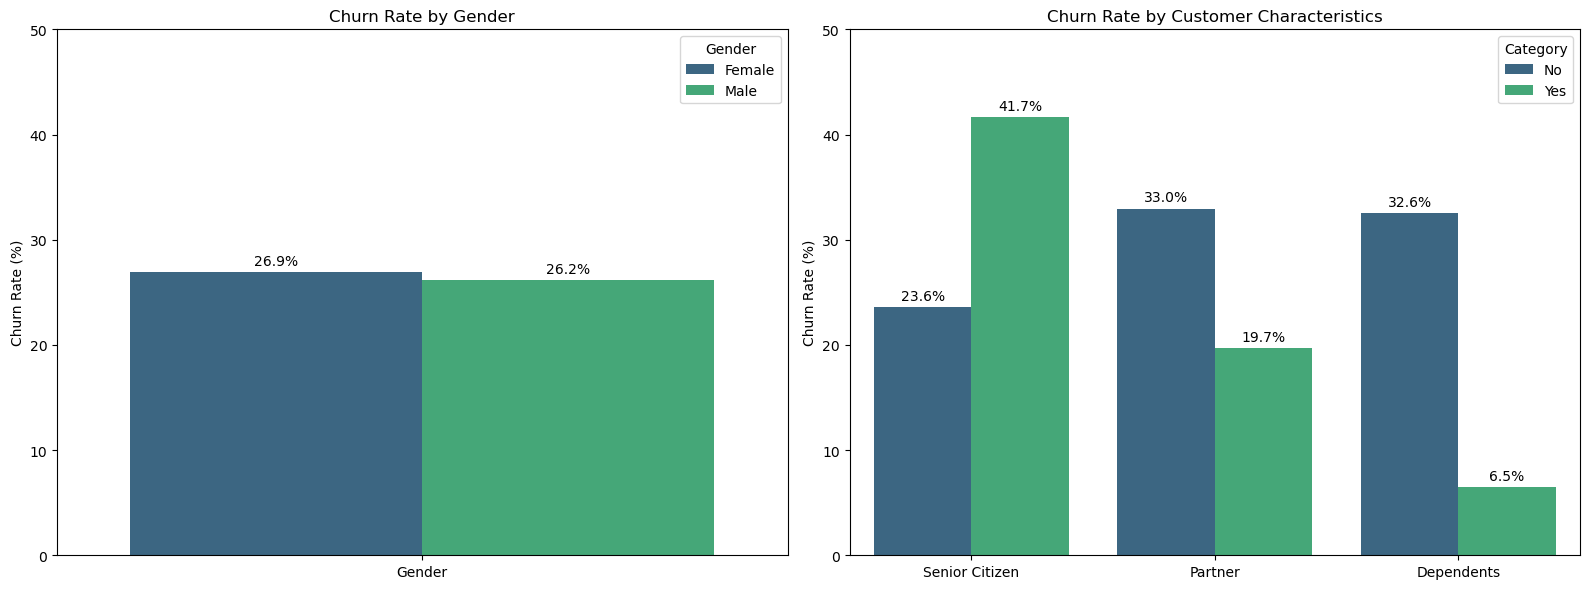

In [48]:
#Plot by demographic: First subplot is gender, second subplot is for senior citizens, and whether the account holder has a partner or dependents.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rows = []
for col in ["Gender", "Senior Citizen", "Partner", "Dependents"]:
    rates = df.groupby(col)["Churn Value"].mean().mul(100)
    for category, rate in rates.items():
        rows.append({"Variable": col, "Category": category, "Churn Rate": rate})
churn_df = pd.DataFrame(rows)


#Subset df by churned and gender
gender_df = churn_df[churn_df["Variable"] == "Gender"]

ax = sns.barplot(data = gender_df, x = "Variable", y = "Churn Rate", hue = "Category", ax = axes[0], palette = 'viridis')

axes[0].set_title("Churn Rate by Gender")
axes[0].set_xlabel("")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_ylim(0, 50)

for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", padding = 3)

#Subset df by churned and senior citizen/partner/dependents
other_df = churn_df[churn_df["Variable"] != "Gender"]

ax = sns.barplot(data = other_df,x = "Variable",y = "Churn Rate",hue = "Category",ax = axes[1], palette = 'viridis')

axes[1].set_title("Churn Rate by Customer Characteristics")
axes[1].set_xlabel("")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_ylim(0, 50)

for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", padding = 3)

# Only keep one legend
axes[0].legend(title = "Gender")
axes[1].legend(title = "Category")

plt.tight_layout()
plt.show()

## Churn Rate by Contract, Internet Service, and Payment Method

Here We group churn rates by columns and calculate their means, multiply by 100 to give a percentage and sort descending for clean viewing.

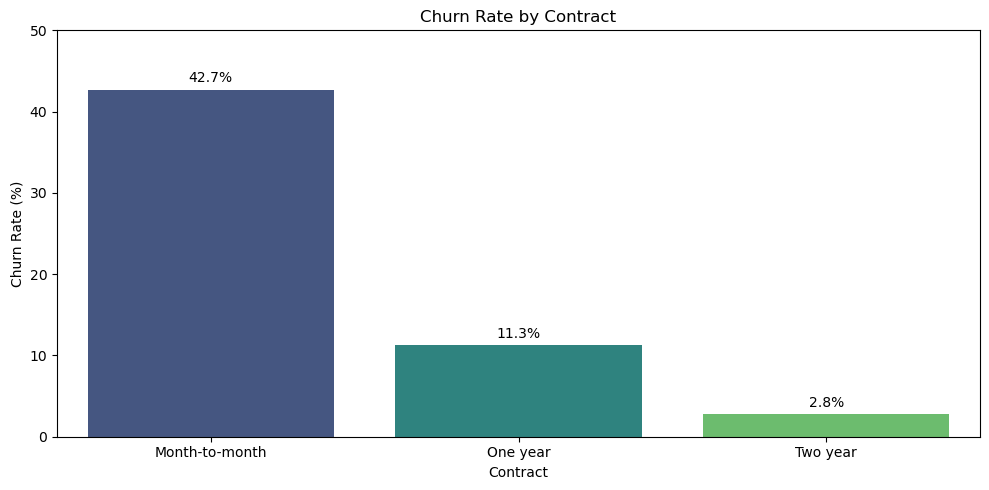

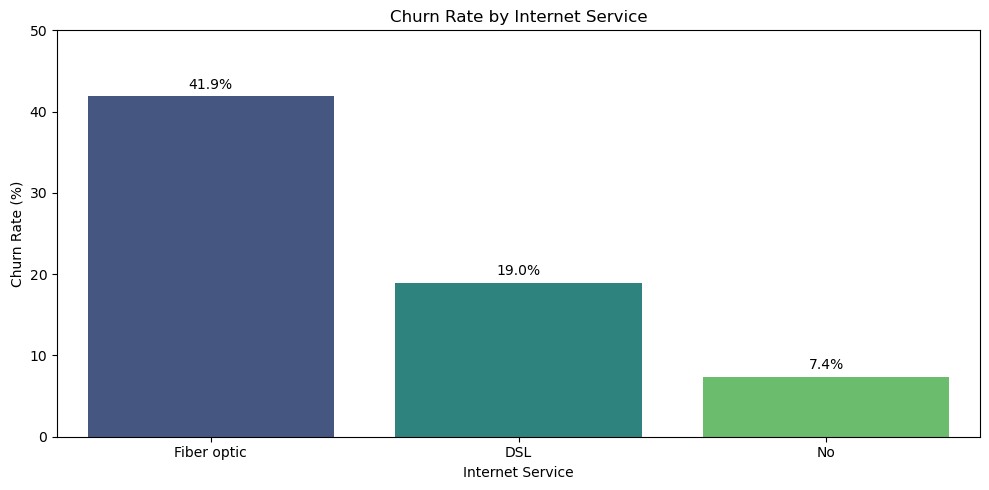

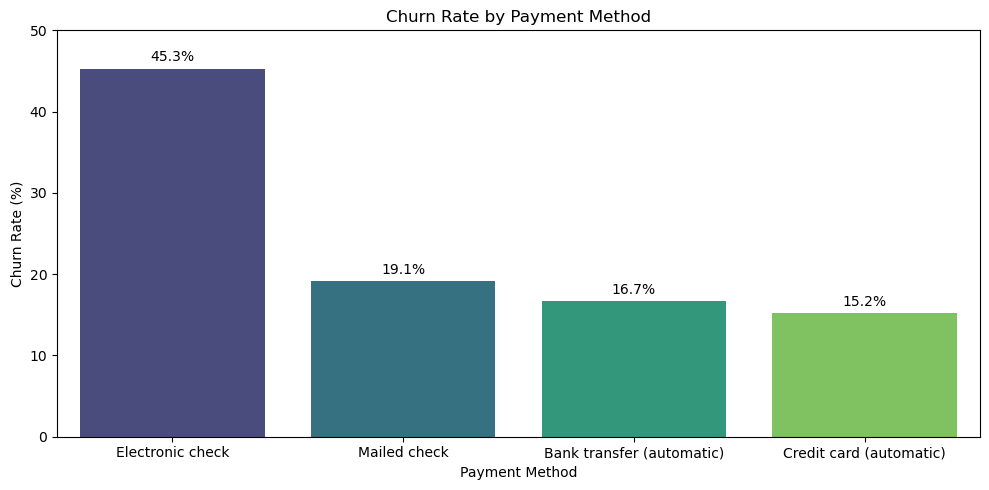

In [49]:
#Plot three graphs to show churn rate by contract type, internet service, and payment method
for col in ["Contract", "Internet Service", "Payment Method"]:
    
    churn_rates = df.groupby(col)["Churn Value"].mean().mul(100).sort_values(ascending = False)

    plt.figure(figsize = (10, 5))
    
    ax = sns.barplot(x = churn_rates.index, y = churn_rates.values, hue = churn_rates.index, palette = 'viridis')

    # Add percentage labels
    for container in ax.containers:
        ax.bar_label(container,fmt="%.1f%%",padding=3)

    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks()
    plt.ylim(0, 50)
    plt.tight_layout()
    plt.show()

## Churn Rate by Tenure and Monthly Charges

Here we investigate how long do churned and current users stay on for, as well as how much they pay (or paid) on average per month

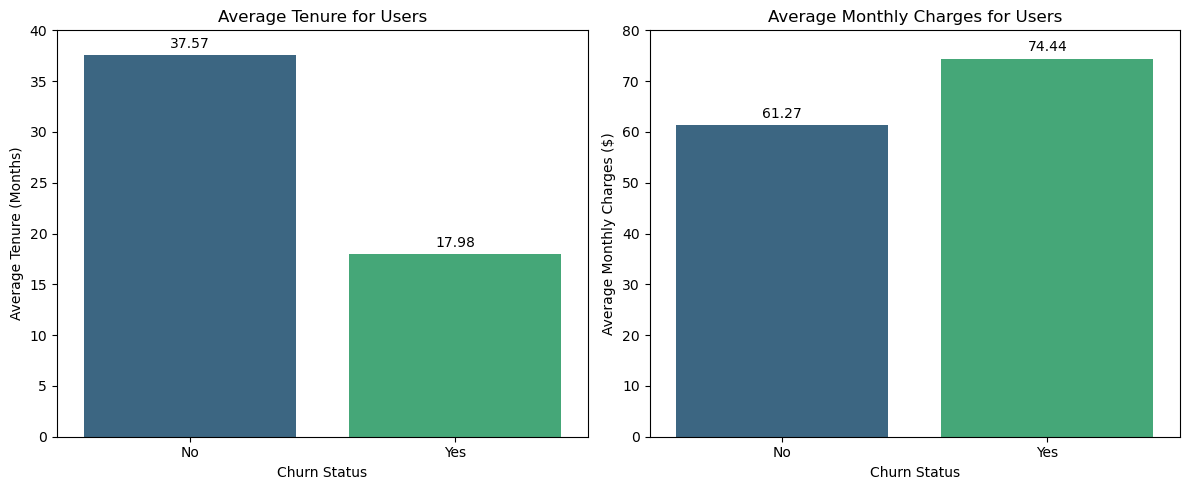

In [50]:
#Summarise churn rates by tenure and monthly charges to see if these impact whether customers stay onboard
churn_summary = (df.groupby("Churn Label")[["Tenure Months", "Monthly Charges"]].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average tenure for churned users
sns.barplot(x=churn_summary.index,y=churn_summary["Tenure Months"],ax=axes[0], hue = churn_summary.index, palette = 'viridis')

axes[0].set_title("Average Tenure for Users")
axes[0].set_xlabel("Churn Status")
axes[0].set_ylim(0, 40)
axes[0].set_ylabel("Average Tenure (Months)")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)


# Average monthly charges for users and if they've churned or not
sns.barplot(x=churn_summary.index,y=churn_summary["Monthly Charges"],ax=axes[1], hue = churn_summary.index, palette = 'viridis')

axes[1].set_title("Average Monthly Charges for Users")
axes[1].set_xlabel("Churn Status")
axes[1].set_ylim(0, 80)
axes[1].set_ylabel("Average Monthly Charges ($)")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

## Reasons for leaving

Of all the customers that gave customers for leaving, why did they leave?

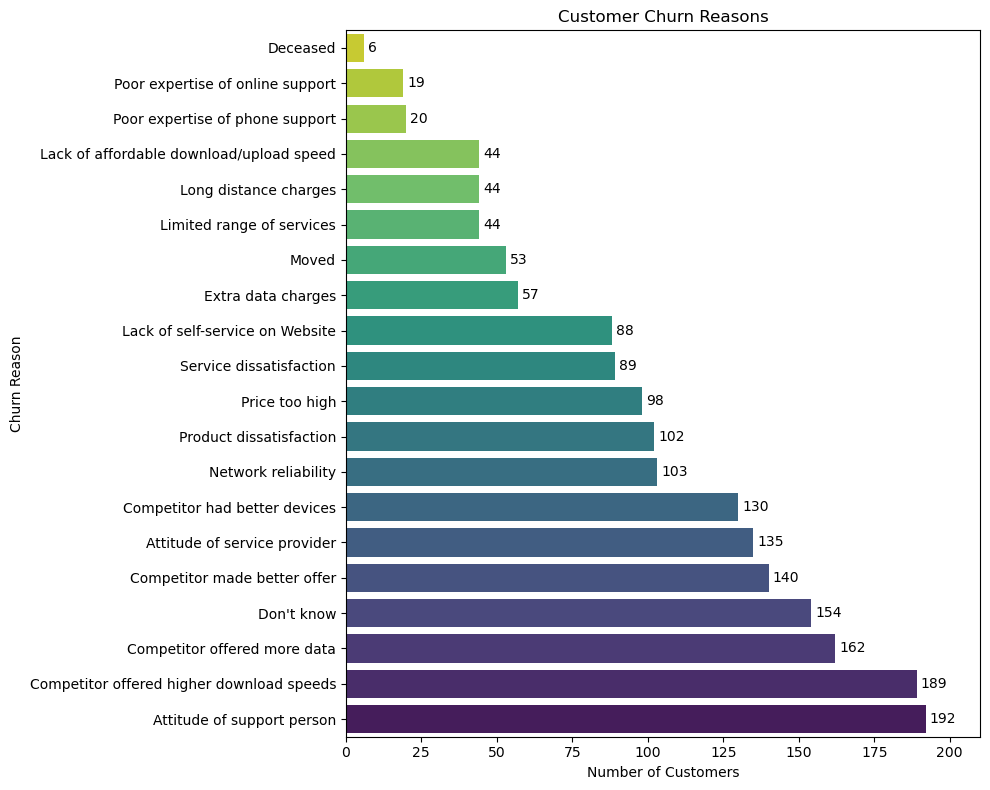

In [51]:
#What reasons have been given for churning
churn_reasons = df["Churn Reason"].dropna().value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 8))

ax = sns.barplot(x=churn_reasons.values,y=churn_reasons.index, hue = churn_reasons.index, palette = 'viridis_r')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Customer Churn Reasons")
plt.xlabel("Number of Customers")
plt.xlim(0, 210)
plt.ylabel("Churn Reason")

plt.tight_layout()
plt.show()

## Churn Rate by Service Add-Ons

Next we will be looking at how churn rates and service add-ons are linked and how popular they are 

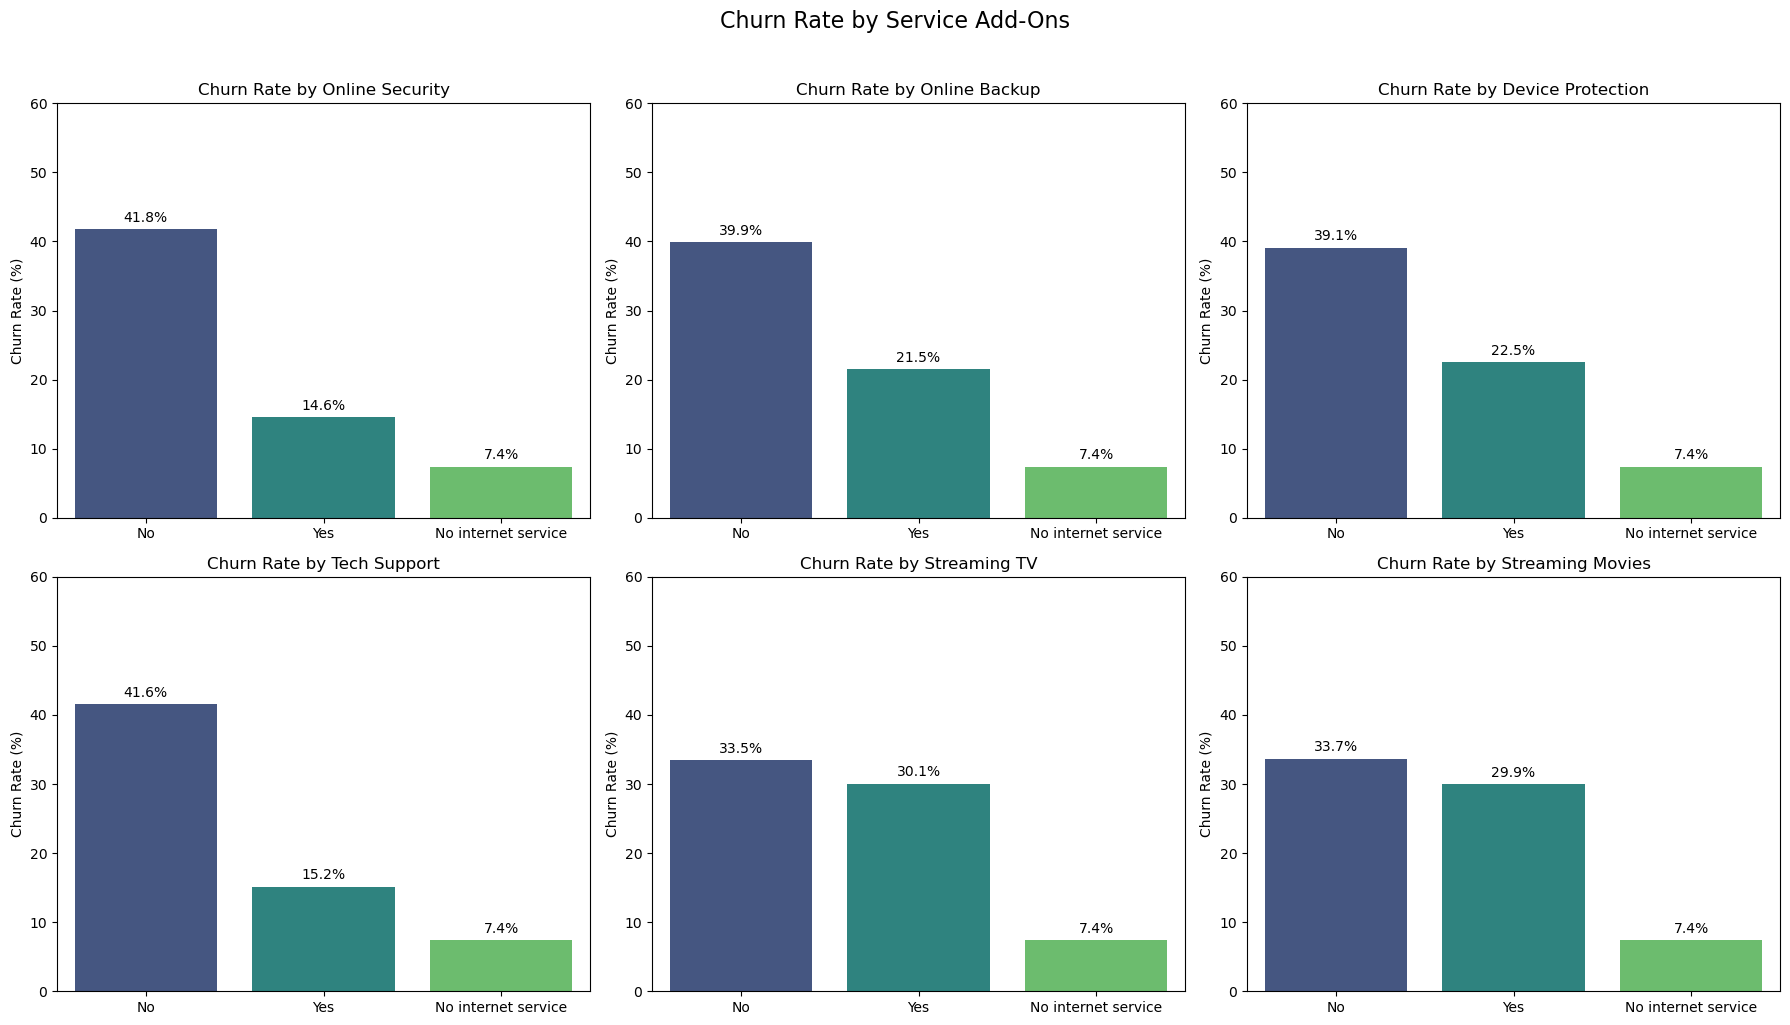

(18, 3)


In [66]:
service_cols = ['Online Security', 'Online Backup', 'Device Protection', 
                'Tech Support', 'Streaming TV', 'Streaming Movies']

rows = []
for col in service_cols:
    rates = df.groupby(col)['Churn Value'].mean().mul(100).sort_values(ascending = False)
    for category, rate in rates.items():
        rows.append({'Variable': col, 'Category': category, 'Churn Rate': rate})

service_df = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    plot_data = service_df[service_df['Variable'] == col]
    ax = sns.barplot(data=plot_data, x='Category', y='Churn Rate', hue='Category', ax=axes[i], palette = 'viridis')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 60)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.suptitle('Churn Rate by Service Add-Ons', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


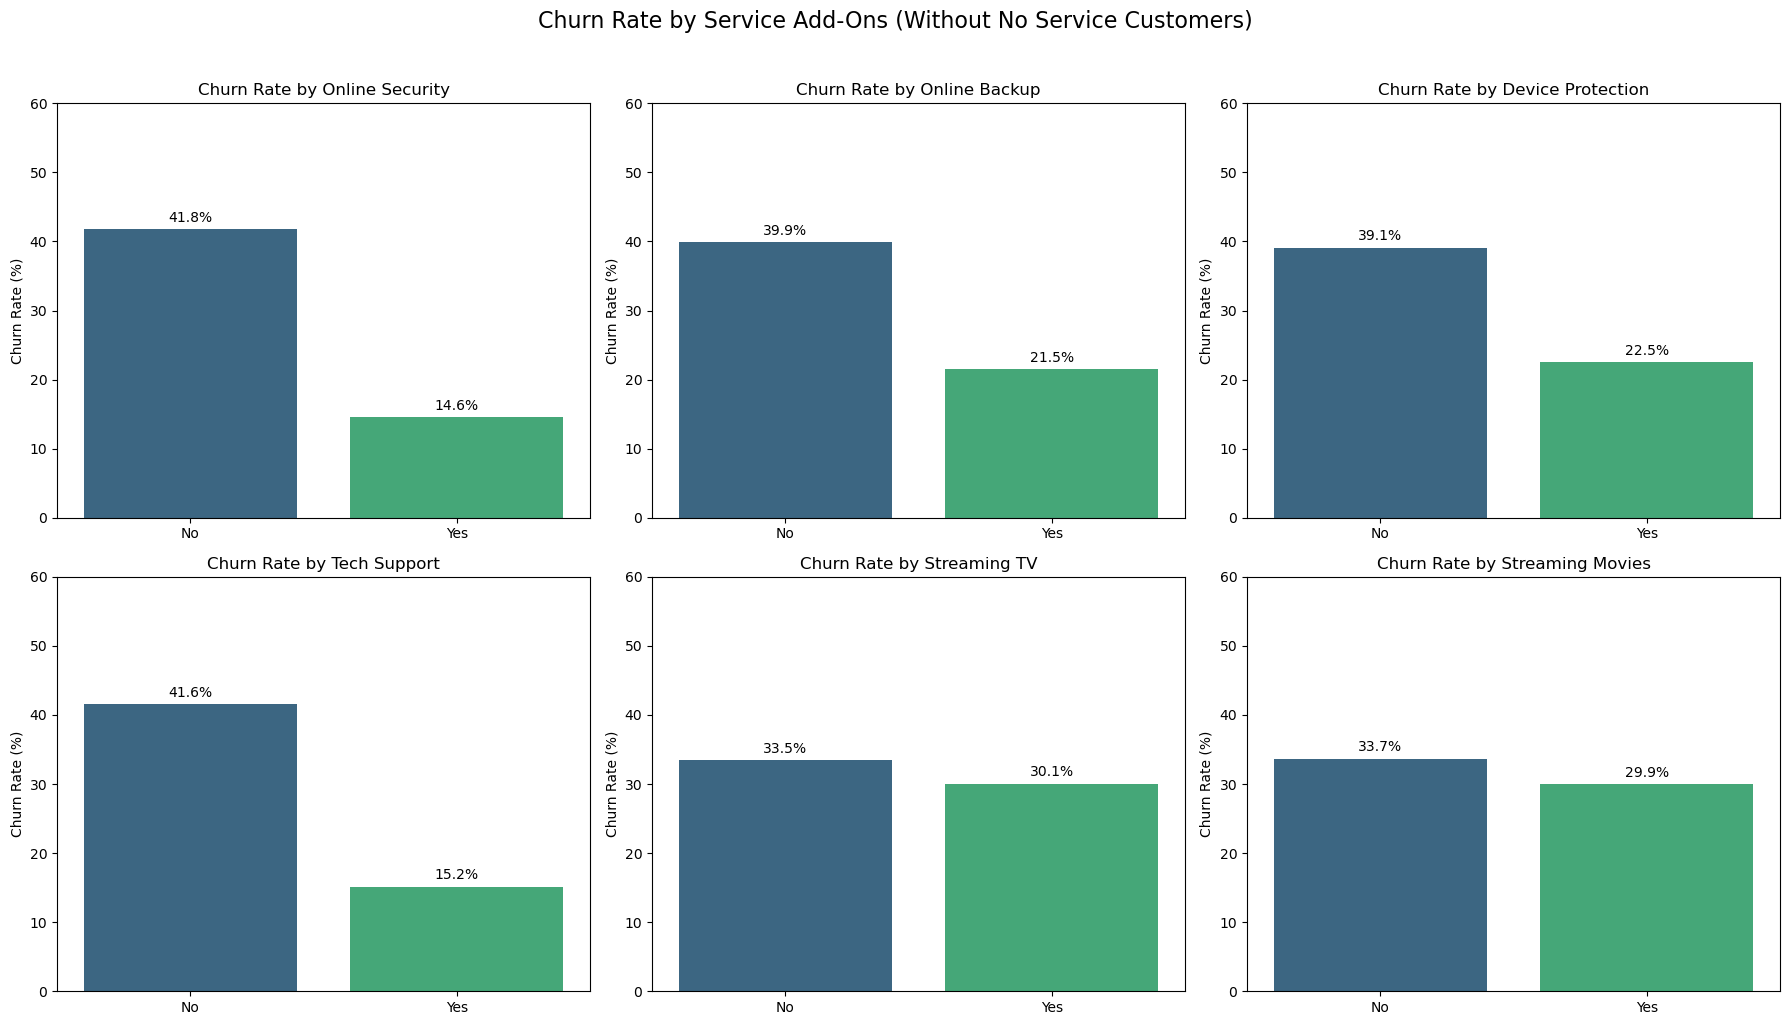

In [53]:
service_cols = ['Online Security', 'Online Backup', 'Device Protection', 
                'Tech Support', 'Streaming TV', 'Streaming Movies']

filtered = df[df[col] != 'No internet service']

rows = []
for col in service_cols:
    rates = filtered.groupby(col)['Churn Value'].mean().mul(100)
    for category, rate in rates.items():
        rows.append({'Variable': col, 'Category': category, 'Churn Rate': rate})

service_df = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    plot_data = service_df[service_df['Variable'] == col]
    ax = sns.barplot(data=plot_data, x='Category', y='Churn Rate', hue='Category', ax=axes[i], palette = 'viridis')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 60)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.suptitle('Churn Rate by Service Add-Ons (Without No Service Customers)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

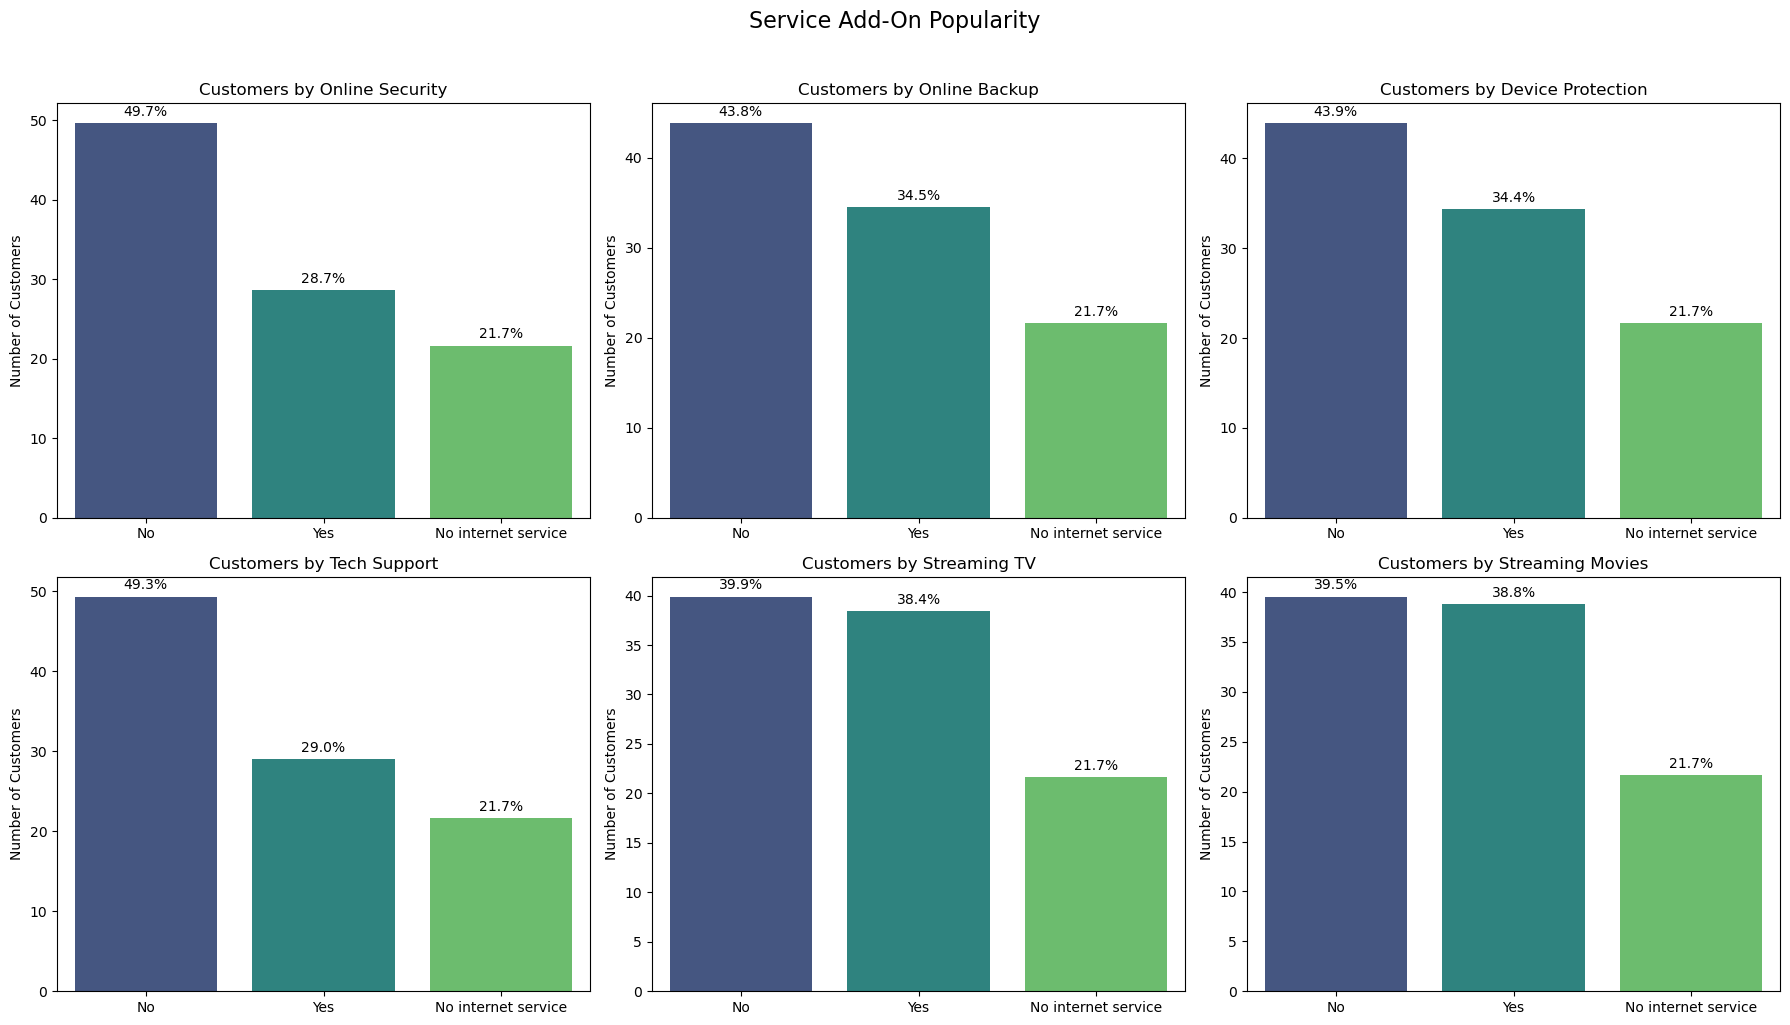

In [54]:
service_cols = ['Online Security', 'Online Backup', 'Device Protection', 
                'Tech Support', 'Streaming TV', 'Streaming Movies']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    counts = df[col].value_counts(normalize = True).mul(100)
    ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, ax=axes[i], palette = 'viridis')
    axes[i].set_title(f'Customers by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Number of Customers')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.suptitle('Service Add-On Popularity', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

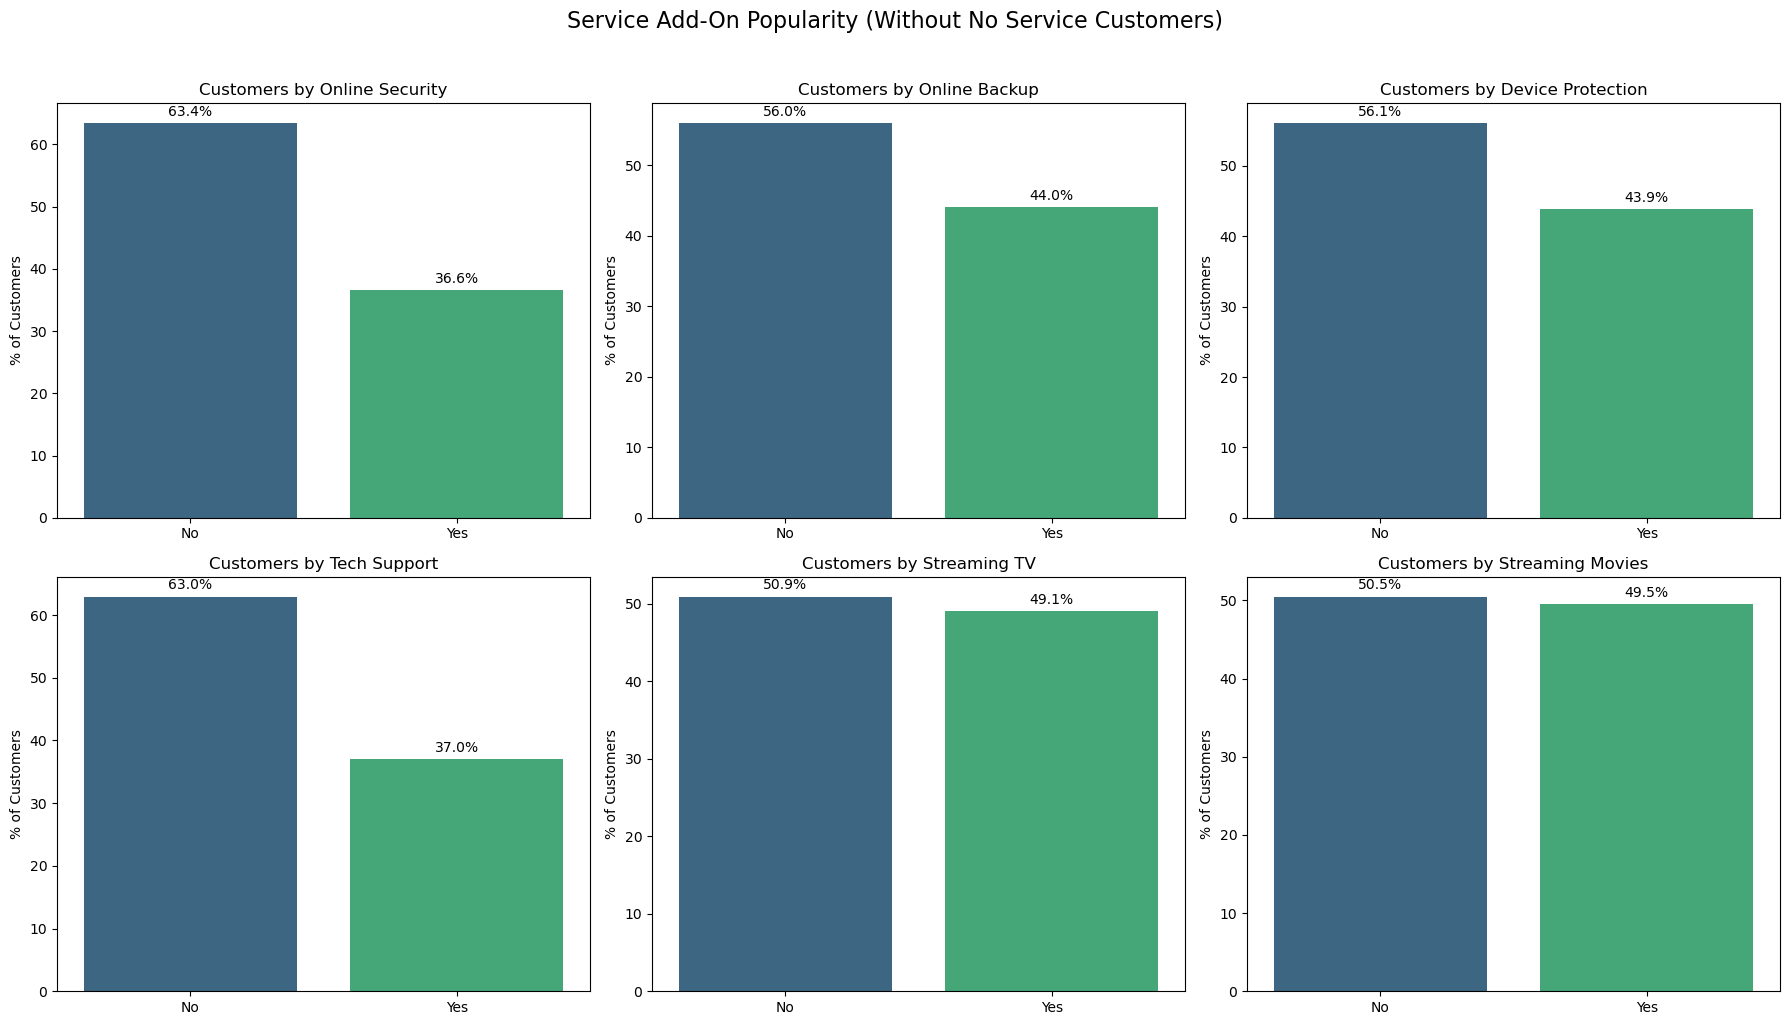

In [55]:
service_cols = ['Online Security', 'Online Backup', 'Device Protection', 
                'Tech Support', 'Streaming TV', 'Streaming Movies']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    filtered = df[df[col] != 'No internet service']
    counts = filtered[col].value_counts(normalize=True).mul(100)
    ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, ax=axes[i], palette = 'viridis')
    axes[i].set_title(f'Customers by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% of Customers')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.suptitle('Service Add-On Popularity (Without No Service Customers)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [56]:
no_services = df[
    (df['Churn Value'] == 1) &
    (df[service_cols] == 'No').all(axis=1)
]

print(f"Total: {len(no_services)}")
no_services[['CustomerID', 'Churn Value'] + service_cols + ['Tenure Months', 'Monthly Charges', 'Total Charges']]

Total: 362


,CustomerID,Churn Value,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Tenure Months,Monthly Charges,Total Charges
1,9237-HQITU,1,No,No,No,No,No,No,2,70.70,151.65
11,6047-YHPVI,1,No,No,No,No,No,No,5,69.70,316.9
26,4846-WHAFZ,1,No,No,No,No,No,No,37,76.50,2868.15
28,0404-SWRVG,1,No,No,No,No,No,No,3,74.40,229.55
32,2372-HWUHI,1,No,No,No,No,No,No,2,44.35,81.25
...,...,...,...,...,...,...,...,...,...,...,...
1861,0723-DRCLG,1,No,No,No,No,No,No,1,74.45,74.45
1863,1122-JWTJW,1,No,No,No,No,No,No,1,70.65,70.65
1865,8775-CEBBJ,1,No,No,No,No,No,No,9,44.20,403.35
1866,6894-LFHLY,1,No,No,No,No,No,No,1,75.75,75.75
